In [1]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    # Monta il drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Inserisci qui il percorso esatto della cartella su Drive.
    # Se è una cartella condivisa standard di cui avete creato una scorciatoia 
    # nel vostro Drive personale, il percorso sarà simile a questo:
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
    
    # Se invece è un "Drive Condiviso" aziendale/universitario:
    # BASE_PATH = '/content/drive/Shareddrives/Nome_Drive/Nome_Progetto/'

else:
    print("Ambiente locale rilevato.")
    # Imposta la directory base in locale. 
    # './' significa la cartella in cui si trova attualmente il notebook.
    # Oppure usa '../' se i notebook sono in una sottocartella e i dati fuori.
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import

In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from datetime import date

I0000 00:00:1781688725.349373    2110 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781688726.259727    2110 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781688729.499708    2110 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Download immagini sintetiche generate con architettura fine-tuned

In [3]:
DEST_DIR     = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')
DEST_DIR_POS = os.path.join(DEST_DIR, 'positive')
DEST_DIR_NEG = os.path.join(DEST_DIR, 'negative')
ZIP_PATH     = os.path.join(DEST_DIR, 'filtered_generated.zip')
SYNTHETIC_DRIVE_ID = '1NKXKcovSlS4-0_zznKmrg1nU0DiXhcFq'

# CONFIGURA QUI: nomi delle cartelle dentro lo ZIP
ZIP_FOLDER_POS = 'positive_filtered_1361_adaptive_mask'   # cartella nello ZIP che contiene le immagini POSITIVE (cancer=1)
ZIP_FOLDER_NEG = 'negative_filtered_1361_adaptive_mask'   # cartella nello ZIP che contiene le immagini NEGATIVE (cancer=0)

def synthetic_data_ready():
    if not os.path.isdir(DEST_DIR_POS) or not os.path.isdir(DEST_DIR_NEG):
        return False
    return (
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_POS)) and
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_NEG))
    )

os.makedirs(DEST_DIR, exist_ok=True)

if not synthetic_data_ready():
    import shutil, tempfile
    print("Immagini sintetiche non trovate, scarico da Google Drive...")
    gdown.download(id=SYNTHETIC_DRIVE_ID, output=ZIP_PATH, quiet=False)

    with tempfile.TemporaryDirectory() as tmp:
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(tmp)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_POS), DEST_DIR_POS)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_NEG), DEST_DIR_NEG)

    os.remove(ZIP_PATH)
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Estrazione completata. File presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")
else:
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Immagini sintetiche già presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")

Immagini sintetiche già presenti:
 - Positivi: 1361
 - Negativi: 1361


#### Verifica presenza file del dataset preprocessato

In [4]:
# ID del file su Google Drive
PROCESSED_DRIVE_ID = "16qdV3arYBeMK7nLZpm3dwGV4lzTLVYmo"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(first_path)
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download.")


Dataset già presente, salto il download.


#### Creazione file CSV dataset di train combinato

- Classe Positiva: Positive Reali + Positive Sintetiche
- Classe Negativa: Negative Reali + Campionamento Negative Sintetiche


In [5]:
OUTPUT_PATH = os.path.join(BASE_PATH, 'data', 'synthetic', 'metadata', 'train_real_synthetic_ft.csv')
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Dati reali
df_real_train = pd.read_csv(TRAIN_CSV_PATH)
n_real_pos = (df_real_train['cancer'] == 1).sum()
n_real_neg = (df_real_train['cancer'] == 0).sum()

# Tutte le sintetiche positive
synth_pos_paths = sorted([
    os.path.join(DEST_DIR_POS, f)
    for f in os.listdir(DEST_DIR_POS) if f.endswith('.png')
])
n_synth_pos = len(synth_pos_paths)

# Logica di bilanciamento 45% positivi / 55% negativi
# tot_pos è fisso → rappresenta il 45% → calcola il totale e i negativi necessari
tot_pos = n_real_pos + n_synth_pos
tot_dataset = round(tot_pos / 0.45)
tot_neg_needed = tot_dataset - tot_pos
n_synth_neg_needed = max(0, tot_neg_needed - n_real_neg)

# Sintetiche negative: campionamento deterministico con indici equamente distanziati
synth_neg_paths_all = sorted([
    os.path.join(DEST_DIR_NEG, f)
    for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png')
])
n_available = len(synth_neg_paths_all)

if n_synth_neg_needed > n_available:
    print(f"ATTENZIONE: richieste {n_synth_neg_needed} sintetiche negative, disponibili {n_available}. Uso tutte.")
    synth_neg_paths = synth_neg_paths_all
else:
    indices = np.linspace(0, n_available - 1, n_synth_neg_needed, dtype=int)
    synth_neg_paths = [synth_neg_paths_all[i] for i in indices]

# Costruzione DataFrame combinato
df_synth_pos_df = pd.DataFrame({'processed_path': synth_pos_paths, 'cancer': 1, 'type': 'generated_ft'})
df_synth_neg_df = pd.DataFrame({'processed_path': synth_neg_paths,  'cancer': 0, 'type': 'generated_ft'})

df_combined = pd.concat(
    [df_real_train.assign(type='real'), df_synth_pos_df, df_synth_neg_df],
    ignore_index=True
)
df_combined.to_csv(OUTPUT_PATH, index=False)

  RIEPILOGO DATASET COMBINATO
  Totale immagini: 3780

              No cancro (0)  Cancro (1)  Totale  % cancer=1
Tipo                                                       
generated_ft            378        1361    1739        78.3
real                   1701         340    2041        16.7

  Totale Cancro (1):     1701  (45.0%)
  Totale No cancro (0):  2079  (55.0%)


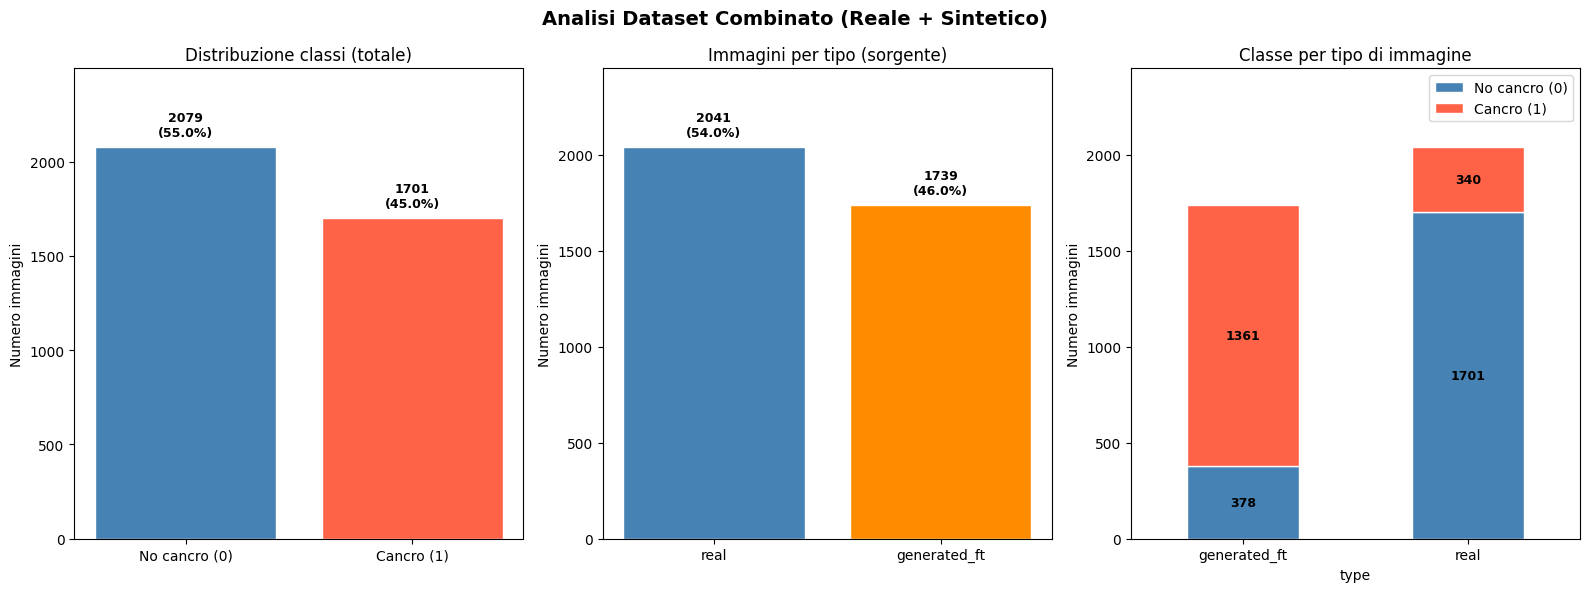

In [6]:
df = df_combined
tot = len(df)

# Statistiche testuali
print("=" * 55)
print("  RIEPILOGO DATASET COMBINATO")
print("=" * 55)
print(f"  Totale immagini: {tot}")
print()

ct = pd.crosstab(df['type'], df['cancer'], rownames=['Tipo'], colnames=['cancer'])
ct.columns = ['No cancro (0)', 'Cancro (1)']
ct['Totale'] = ct.sum(axis=1)
ct['% cancer=1'] = (ct['Cancro (1)'] / ct['Totale'] * 100).round(1)
print(ct.to_string())
print()

n_pos = (df['cancer'] == 1).sum()
n_neg = (df['cancer'] == 0).sum()
print(f"  Totale Cancro (1):    {n_pos:>5}  ({n_pos/tot*100:.1f}%)")
print(f"  Totale No cancro (0): {n_neg:>5}  ({n_neg/tot*100:.1f}%)")
print("=" * 55)

# Grafici
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Analisi Dataset Combinato (Reale + Sintetico)", fontsize=14, fontweight='bold')

def label_bars(ax, bars, total, margin_frac=0.20):
    ymax = max(b.get_height() for b in bars)
    ax.set_ylim(0, ymax * (1 + margin_frac))
    for bar in bars:
        v = int(bar.get_height())
        ax.text(bar.get_x() + bar.get_width() / 2, v + ymax * 0.02,
                f"{v}\n({v/total*100:.1f}%)", ha='center', va='bottom',
                fontweight='bold', fontsize=9)

# Distribuzione classi globale
counts = df['cancer'].value_counts().sort_index()
bars = axes[0].bar(['No cancro (0)', 'Cancro (1)'], counts.values,
                   color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Distribuzione classi (totale)')
axes[0].set_ylabel('Numero immagini')
label_bars(axes[0], bars, tot)

# Distribuzione per tipo
type_counts = df['type'].value_counts()
bars2 = axes[1].bar(type_counts.index, type_counts.values,
                    color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Immagini per tipo (sorgente)')
axes[1].set_ylabel('Numero immagini')
label_bars(axes[1], bars2, tot)

# Stacked bar tipo x classe
ct_plot = pd.crosstab(df['type'], df['cancer'])
ct_plot.plot(kind='bar', stacked=True, ax=axes[2],
             color=['steelblue', 'tomato'], rot=0, edgecolor='white')
axes[2].set_title('Classe per tipo di immagine')
axes[2].set_ylabel('Numero immagini')
axes[2].legend(['No cancro (0)', 'Cancro (1)'], loc='upper right')
stacked_max = ct_plot.sum(axis=1).max()
axes[2].set_ylim(0, stacked_max * 1.20)
for container in axes[2].containers:
    axes[2].bar_label(container, label_type='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Configurazione

In [7]:
# Cartella esperimento
OUTPUT_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260617_real_synth_resnet50_fine_tuned_batch_size_16')
os.makedirs(OUTPUT_EXP_DIR, exist_ok=True)
print(OUTPUT_EXP_DIR)

../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv


I0000 00:00:1781688773.736835    2110 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


#### Preparazione Dati e Pipeline

In [9]:
# 1. Carica e filtra il CSV
df_train = pd.read_csv(OUTPUT_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

# 2. Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    #img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti, nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False) # Da mettere a True se vuoi data augmentation
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 0.9090909090909091, 1: 1.1111111111111112}


#### Salvataggio configurazione utilizzata per esperimento corrente

In [10]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_EXP_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "ResNet-50",
        "weights": "imagenet",
        "input_shape": list(IMG_SIZE) + [3],
        "include_top": False,
    },
    "head": {
        "pooling": "GlobalAveragePooling2D",
        "dense_units": 256,
        "l2_regularization": 1e-4,
        "activation": "LeakyReLU(negative_slope=0.1)",
        "dropout": 0.5,
        "output": "Dense(1, sigmoid)",
    },
    "preprocessing": {
        "img_size": list(IMG_SIZE),
        "normalization": "ImageNet mean/std",
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": OUTPUT_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "class_weight": "balanced",
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalCrossentropy",
        "BinaryFocalCrossentropy_gamma": 2.0,
        "BinaryFocalCrossentropy_alpha": 0.75,
        "max_epochs": 30,
        "fine_tune_from_layer": "conv4_block5_1_conv",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
        "class_weight": "none",
    },
}

config_path = os.path.join(OUTPUT_EXP_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")


Configurazione esperimento salvata in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/experiment_config.json


#### Costruzione dell'Architettura ResNet-50

In [11]:
def build_base_model():
    # Carica il backbone ResNet-50 pre-addestrato
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    
    # Congela il backbone per la Fase 1
    base_model.trainable = False
    
    # Costruisci l'architettura completa
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    
    # training=False è fondamentale qui per la Batch Normalization
    x = base_model(inputs, training=False) 
    
    # Global Average Pooling (scelta ottimale per ridurre i parametri)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Custom Head con LeakyReLU
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x) # alpha è la pendenza per i valori negativi
    x = layers.Dropout(0.5)(x)
    
    # Output binario (1 neurone con sigmoid)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name="real_synth_resnet50")
    return model, base_model

model, base_model = build_base_model()
model.summary()

Model: "real_synth_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Fase 1: Addestramento Custom Head

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', 
        patience=7, 
        restore_best_weights=True, 
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_fase1_best.keras'), 
        monitor='val_auc', 
        save_best_only=True, 
        mode='max'
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_EXP_DIR, 'training_log_fase1.csv'),
        separator=',',
        append=False
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781689212.180243    2401 service.cc:153] XLA service 0x7cfdb006b860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781689212.180355    2401 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781689212.812240    2401 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781689215.426887    2401 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781689215.603396    2401 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12190__.197
I0000 00:00:1781689226.986893    2401 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6816 - auc: 0.7278 - loss: 0.7284 - precision: 0.6287 - recall: 0.6577

I0000 00:00:1781689238.710873    2403 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12190__.197


237/237 ━━━━━━━━━━━━━━━━━━━━ 61s 162ms/step - accuracy: 0.6963 - auc: 0.7455 - loss: 0.6894 - precision: 0.6513 - recall: 0.6996 - val_accuracy: 0.7574 - val_auc: 0.6129 - val_loss: 0.5325 - val_precision: 0.1765 - val_recall: 0.1233
Epoch 2/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.7193 - auc: 0.7801 - loss: 0.6211 - precision: 0.6733 - recall: 0.7307 - val_accuracy: 0.7735 - val_auc: 0.6207 - val_loss: 0.5451 - val_precision: 0.2593 - val_recall: 0.1918
Epoch 3/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.7307 - auc: 0.7911 - loss: 0.5983 - precision: 0.6827 - recall: 0.7501 - val_accuracy: 0.7346 - val_auc: 0.6366 - val_loss: 0.5790 - val_precision: 0.2471 - val_recall: 0.2877
Epoch 4/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.7437 - auc: 0.8062 - loss: 0.5772 - precision: 0.6976 - recall: 0.7596 - val_accuracy: 0.7757 - val_auc: 0.6312 - val_loss: 0.5135 - val_precision: 0.2222 - val_recall: 0.1370
Epoch 5/25
237/237 ━━━━━━━━━━━━━━━

#### Fase 2: Fine Tuning

In [13]:
base_model.trainable = True
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'conv4_block5_1_conv':  # corrisponde a ~31% di layer sbloccati, come in EfficientNetB3
        set_trainable = True
    layer.trainable = set_trainable

# Freeze dei BatchNorm: anche nei layer sbloccati sopra,
# le statistiche BN restano quelle di ImageNet (più stabili con batch size piccolo)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Totale layer nel base_model: {len(base_model.layers)}")
n_trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer trainable nel base_model: {n_trainable_layers}/{len(base_model.layers)}")

'''
def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn
'''

# Ricompila il modello con un Learning Rate MOLTO basso (fondamentale!)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss=keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.75,
        gamma=2.0,
        from_logits=False
    ),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', # stabile non oscilla 
        patience=5, # riducendo patience il segnale è più pulito
        min_delta=1e-3,
        restore_best_weights=True, 
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_final_best.keras'), 
        monitor='val_auc', # salva il migliore per AUC
        save_best_only=True, 
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', 
        factor=0.5, 
        patience=3,
        mode='max', 
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_EXP_DIR, 'training_log_fase2.csv'),
        separator=',',
        append=False
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_final_best.keras')}")

Totale layer nel base_model: 175
Layer trainable nel base_model: 36/175
Epoch 1/30


I0000 00:00:1781689477.614176    2402 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62180__.197


236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7337 - auc: 0.8131 - loss: 0.1071 - precision: 0.6793 - recall: 0.7834

I0000 00:00:1781689512.286567    2403 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62180__.197


237/237 ━━━━━━━━━━━━━━━━━━━━ 84s 218ms/step - accuracy: 0.7159 - auc: 0.7933 - loss: 0.1116 - precision: 0.6557 - recall: 0.7760 - val_accuracy: 0.7391 - val_auc: 0.6484 - val_loss: 0.0982 - val_precision: 0.2267 - val_recall: 0.2329 - learning_rate: 1.0000e-05
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.7103 - auc: 0.7909 - loss: 0.1063 - precision: 0.6458 - recall: 0.7889 - val_accuracy: 0.7529 - val_auc: 0.6458 - val_loss: 0.1092 - val_precision: 0.2727 - val_recall: 0.2877 - learning_rate: 1.0000e-05
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.7587 - auc: 0.8382 - loss: 0.0928 - precision: 0.6867 - recall: 0.8530 - val_accuracy: 0.7391 - val_auc: 0.6323 - val_loss: 0.1112 - val_precision: 0.2338 - val_recall: 0.2466 - learning_rate: 1.0000e-05
Epoch 4/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.7704 - auc: 0.8575 - loss: 0.0869 - precision: 0.6924 - recall: 0.8812 - val_accuracy: 0.7208 - val_auc: 0.6394 - val_loss: 0.

#### Visualizzazione Curve di Training

Analisi Overfitting - Fase 1 (Feature Extraction):
Grafico salvato in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/figures/training_history_fase1.png


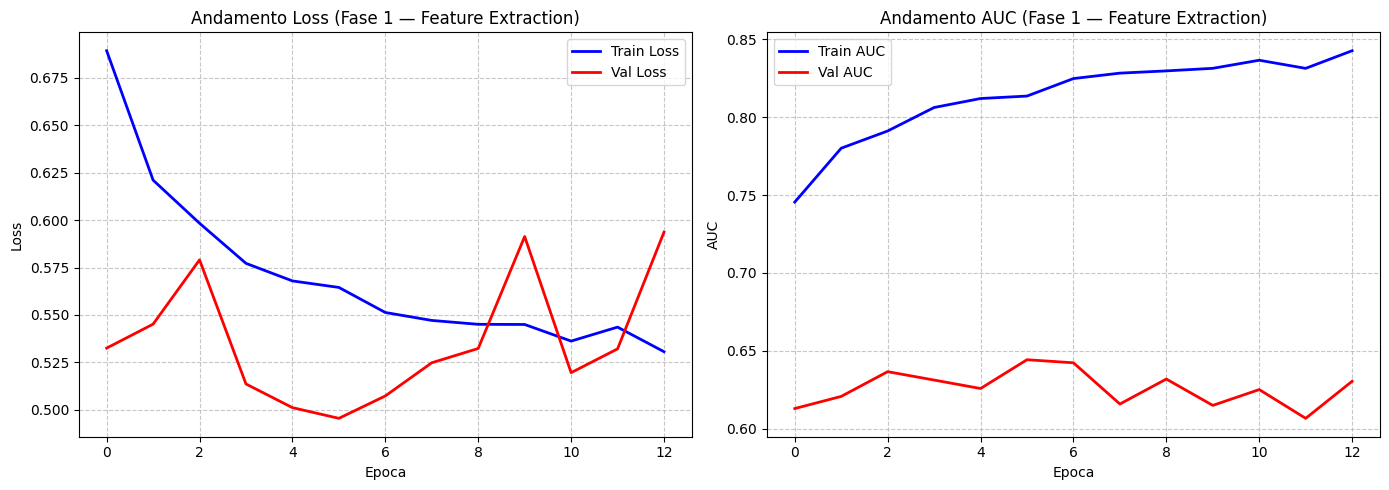

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/figures/training_history_fase2.png


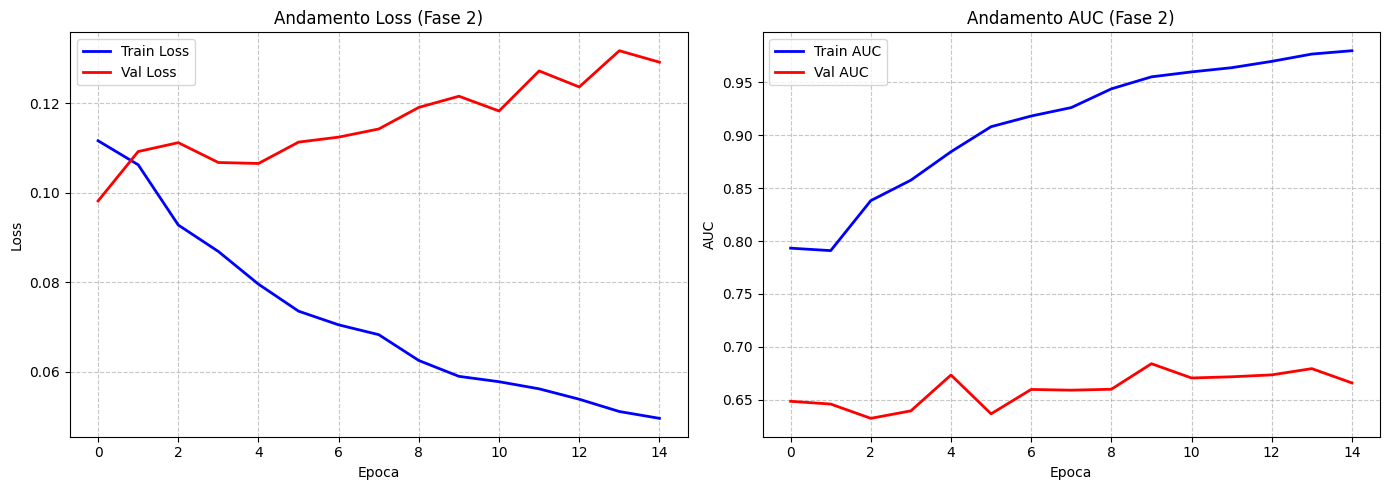

In [15]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Feature Extraction):")
plot_training_history(
    history_phase1, "(Fase 1 — Feature Extraction)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione su Validation Set

AUC: 0.6843
Soglia ottimale: 0.269
              precision    recall  f1-score   support

   No cancro       0.91      0.55      0.69       364
      Cancro       0.25      0.74      0.37        73

    accuracy                           0.59       437
   macro avg       0.58      0.65      0.53       437
weighted avg       0.80      0.59      0.64       437

Metriche salvate in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/val_metrics.json


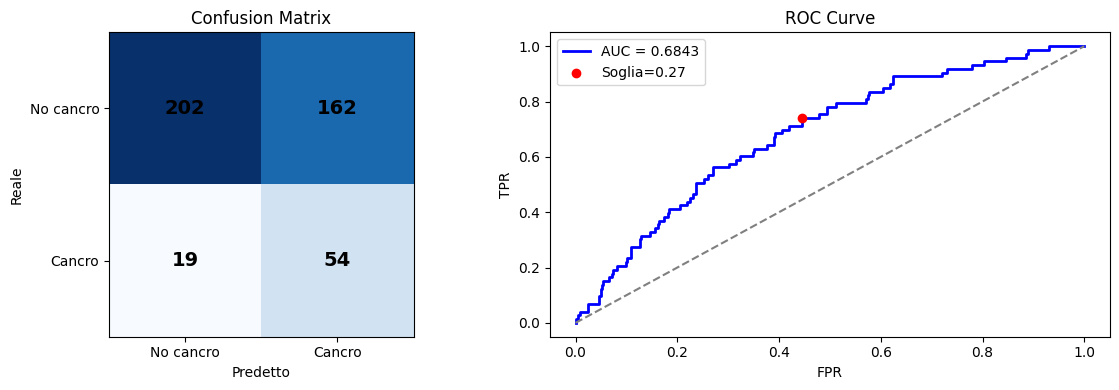

Figura salvata in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/figures/val_confusion_roc.png


In [16]:
import json
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_final_best.keras')
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'backbone': 'ResNet-50',
    'experiment_name': os.path.basename(OUTPUT_EXP_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_EXP_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM

Modello caricato: real_synth_resnet50


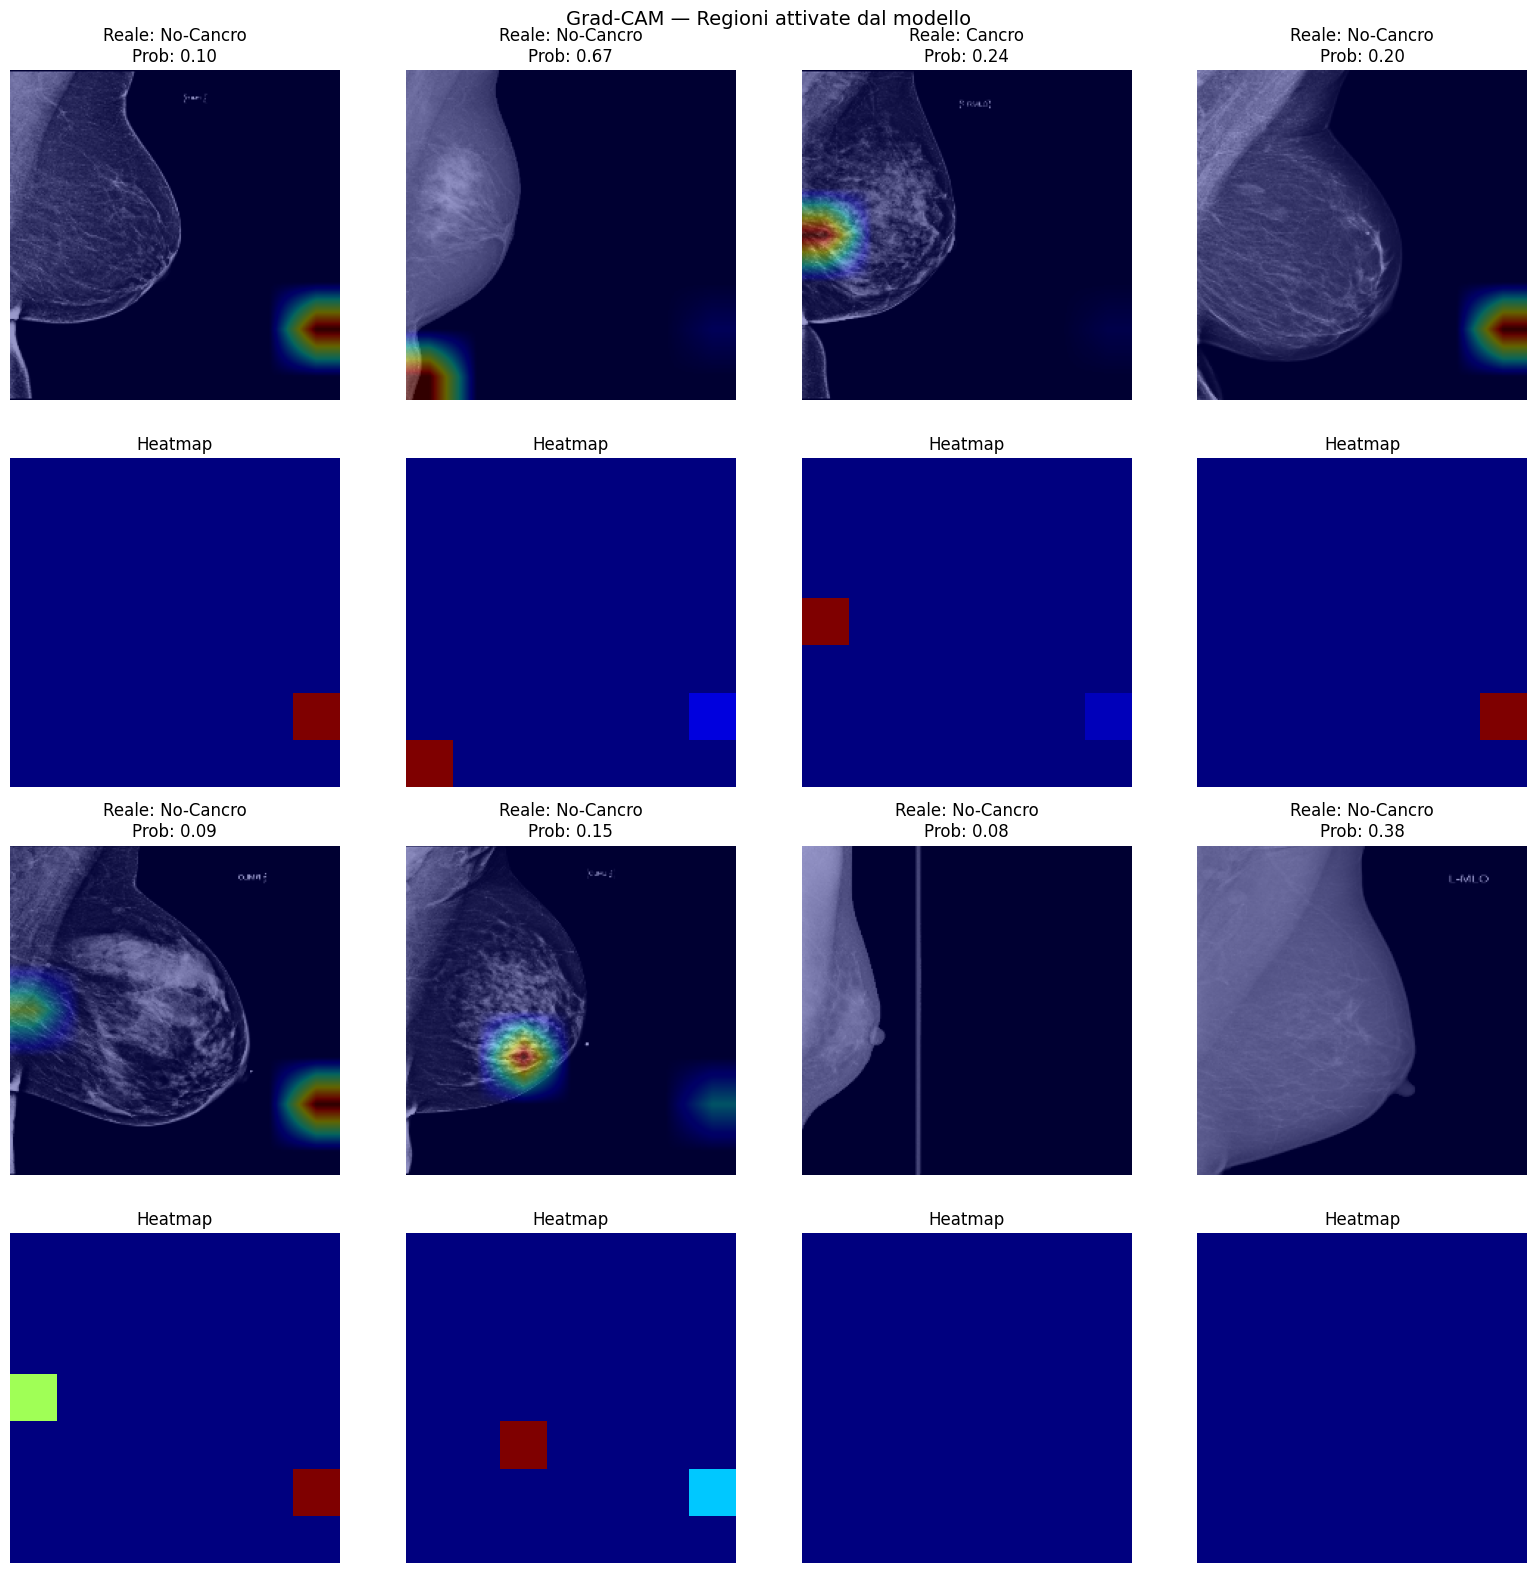

Grad-CAM salvato in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/figures/gradcam_examples.png


In [17]:
# Carica il modello già allenato (nessun custom_objects necessario)
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')

best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_final_best.keras')
)
print(f"Modello caricato: {best_model.name}")


def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')
    # Layer dopo il backbone nell'outer model: GAP → Dense → BN → LeakyReLU → Dropout → Dense
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]

    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)  # (1, H, W, 2048) — ha dimensioni spaziali
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()



def show_gradcam(img_tensor, heatmap, ax, title=""):
    """Sovrappone la heatmap all'immagine originale de-normalizzata."""
    # De-normalizza per visualizzazione
    img_vis = img_tensor.numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    img_vis_gray = img_vis[:, :, 0]  # canale singolo (mammografia)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis_gray, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title)
    ax.axis('off')


# Mostra Grad-CAM su 8 esempi del validation set
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
sample_count = 0
for imgs, labels in val_ds:
    for i in range(len(imgs)):
        if sample_count >= 8:
            break
        img = imgs[i:i+1]
        label = int(labels[i].numpy())
        prob = float(best_model.predict(img, verbose=0)[0][0])
        heatmap = make_gradcam_heatmap(img, best_model)

        row_img = (sample_count // 4) * 2       # 0 o 2
        row_heat = row_img + 1                  # 1 o 3
        col = sample_count % 4                  # 0,1,2,3

        show_gradcam(imgs[i], heatmap, axes[row_img, col],
                     title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
        axes[row_heat, col].imshow(heatmap, cmap='jet')
        axes[row_heat, col].set_title("Heatmap")
        axes[row_heat, col].axis('off')
        sample_count += 1
    if sample_count >= 8:
        break

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")

#### Grad-CAM su immagini sintetiche

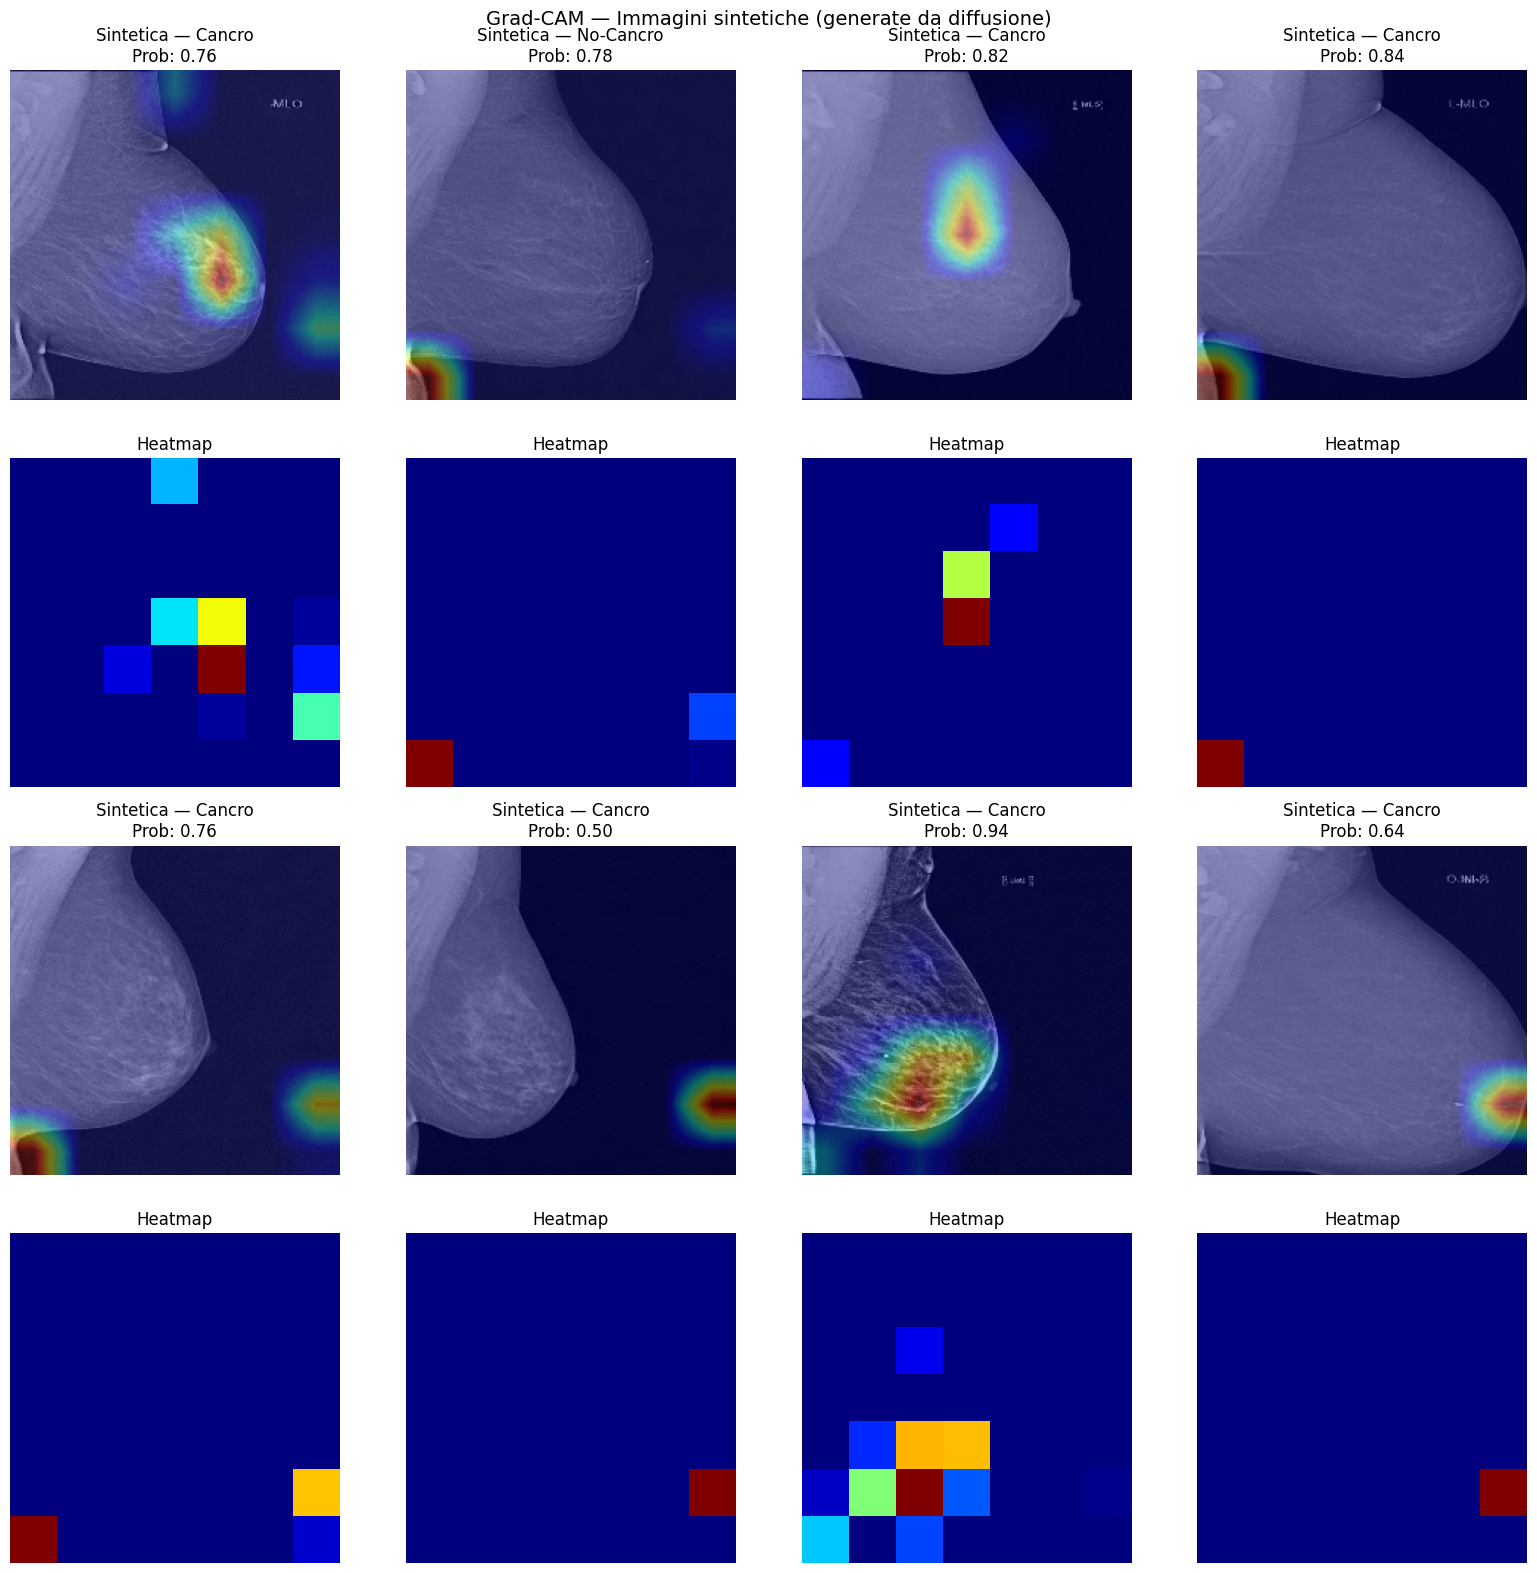

Grad-CAM sintetiche salvato in: ../experiments/exp20260617_real_synth_resnet50_fine_tuned_batch_size_16/figures/gradcam_synthetic_examples.png


In [19]:
# Dataset con sole immagini sintetiche
df_synth = pd.concat([df_synth_pos_df, df_synth_neg_df], ignore_index=True)
synth_ds = make_dataset(df_synth[['processed_path', 'cancer']], shuffle=False, augment_data=False)

# Raccoglie tutte le immagini sintetiche e campiona 8 casuali
all_synth_imgs, all_synth_labels = [], []
for imgs, labels in synth_ds:
    for i in range(len(imgs)):
        all_synth_imgs.append(imgs[i])
        all_synth_labels.append(int(labels[i].numpy()))

np.random.seed(SEED)  # per avere riproducibilità
indices_synth = np.random.choice(len(all_synth_imgs), size=8, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, idx in enumerate(indices_synth):
    img = tf.expand_dims(all_synth_imgs[idx], 0)
    label = all_synth_labels[idx]
    prob = float(best_model.predict(img, verbose=0)[0][0])
    heatmap = make_gradcam_heatmap(img, best_model)

    row_img = (i // 4) * 2       # 0 o 2
    row_heat = row_img + 1       # 1 o 3
    col = i % 4                 # 0,1,2,3

    show_gradcam(all_synth_imgs[idx], heatmap, axes[row_img, col],
                 title=f"Sintetica — {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
    axes[row_heat, col].imshow(heatmap, cmap='jet')
    axes[row_heat, col].set_title("Heatmap")
    axes[row_heat, col].axis('off')

plt.suptitle("Grad-CAM — Immagini sintetiche (generate da diffusione)", fontsize=14)
plt.tight_layout()
gradcam_synth_path = os.path.join(FIGURES_DIR, 'gradcam_synthetic_examples.png')
fig.savefig(gradcam_synth_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM sintetiche salvato in: {gradcam_synth_path}")